In [1]:
import os
from pathlib import Path
import torch
import numpy as np
import matplotlib.pylab as plt
from omegaconf import OmegaConf
import librosa

%matplotlib inline

In [2]:
from diffusion_hub.diffusion.spect_model import GradLogPEstimator2d

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
estimator = GradLogPEstimator2d(dim=128, pe_scale=1)


# loading the checkpoint
chkpt_path = Path('/depot/jgmakin/data/bilal/pretrained_models/hifi_spect_diff/checkpoint-steps-2000000.pth')
checkpoint = torch.load(chkpt_path, map_location="cpu")['model_state_dict']
checkpoint = {
    (k[10:] if k.startswith('estimator') else k): v
    for k, v in checkpoint.items()
}
estimator.load_state_dict(checkpoint)


/tmp/ipykernel_1234537/752875075.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(chkpt_path, map_location="cpu")['model_state_dict']


<All keys matched successfully>

#### using original sampler...

In [ ]:
# using original sampler ...

from diffusion_hub.diffusion import SDEDiffusion
diff_model = SDEDiffusion(estimator, beta_min=0.05, beta_max=20)

diff_model.eval()
diff_model = diff_model.to(device)

z = torch.randn(4, 80, 256).cuda()
samples = diff_model.reverse_diffusion(z, n_timesteps=100)

In [ ]:
idx=1

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(samples[idx].squeeze().cpu().numpy(), origin='lower', cmap='viridis')
# plt.colorbar()
plt.show()

#### using EDM sampler...

In [6]:
from diffusion_hub.diffusion import VPScore
edm_diff = VPScore(estimator)

shape = edm_diff.get_init_shape(batch_size=4)
with torch.no_grad():
    samples = edm_diff.reverse_diffusion(n_timesteps=100, shape=shape)

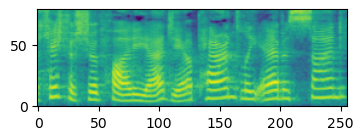

In [7]:
idx=1

fig, ax = plt.subplots(figsize=(4, 3))
plt.imshow(samples[idx].squeeze().cpu().numpy(), origin='lower', cmap='viridis')
# plt.colorbar()
plt.show()

In [8]:
from IPython.display import Audio

idx=1
audio = librosa.feature.inverse.mel_to_audio(
        samples[idx].squeeze().cpu().numpy(),
        sr=22050,
        n_fft=1024,
        hop_length=256,
        win_length=1024,
        window='hamming',
        )

Audio(audio, rate=22050)

### hifi-GAN

In [16]:
from diffusion_hub.models import load_hifigan

generator = load_hifigan().cuda()

/depot/jgmakin/data/bilal/env/diffusion/lib/python3.8/site-packages/torch/nn/utils/weight_norm.py:134: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/home/ahmedb/projects/diffusion-hub/diffusion_hub/models/vocoder.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We re

In [16]:
wavs = generator(samples).detach()

In [17]:
idx=1
Audio(wavs[idx].squeeze().cpu().numpy(), rate=22050)